# Yelp Review Star Rating Classification
Lipai Huang (630003919) 

Final deliverable for CSCE 676. Built on Checkpoint 1 and Checkpoint 2. This notebook looks at why middle star ratings are harder to classify than extreme ones in the Yelp Review Full dataset.

```
Collaboration Declaration
1) Collaborators:
- None.

2) Web Sources:
- Yelp Review Full: https://huggingface.co/datasets/Yelp/yelp_review_full

3) AI Tools:
- Claude Code (used for code scaffolding, writing assistance and readme summary).

4) Paper / Method Citations:
- Zhang, X., Zhao, J. and LeCun, Y., 2015. Character-level convolutional networks for text classification. Advances in neural information processing systems, 28.
- Blei, D.M., Ng, A.Y. and Jordan, M.I., 2003. Latent Dirichlet Allocation. Journal of Machine Learning Research, 3, pp.993-1022.
```

## Setup

In [4]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml

from datasets import load_dataset
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.decomposition import LatentDirichletAllocation
from scipy.stats import entropy

import warnings
warnings.filterwarnings('ignore')

pd.set_option("display.max_colwidth", 200)
plt.rcParams["figure.dpi"] = 120

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

if os.path.exists("config.yaml"):
    with open("config.yaml") as f:
        cfg = yaml.safe_load(f) or {}
    if cfg.get("HF_TOKEN"):
        os.environ["HF_TOKEN"] = cfg["HF_TOKEN"]

## 1. Motivation

This project works on the Yelp Review Full dataset from Hugging Face. The task is 5-class star rating classification, with 650K training reviews and 50K test reviews. The labels are balanced across all five stars. The starting point came from Checkpoint 1. A simple TF-IDF + Logistic Regression baseline reached around 53% accuracy on the test set. That number is not surprising for a 5-class problem where adjacent labels share a lot of language. What stood out was the per-class breakdown. The model handled 1 star and 5 star reviews reasonably well, but performance dropped on 2, 3, and 4 stars. The middle ratings looked harder to separate, while extreme ratings had clearer signal. The gap was large enough that it did not look like normal variance. The rest of this notebook is organized around that observation. The three research questions in the next section each look at this gap from a different angle: review length, choice of text representation, and topic structure.

## 2. Research Questions

The notebook continues with three research questions. Each one looks at a different possible reason why middle ratings are harder to classify than extreme ones.

**RQ1. Does review length explain part of the gap?**

EDA in Checkpoint 1 showed that 1 star reviews tend to be longer than 5 star ones. If short and long reviews carry different amounts of signal, length itself could be a factor in the per-class gap.


**RQ2. Does the choice of text representation change the gap?**

A pilot run in Checkpoint 2 showed that TF-IDF beats CountVectorizer overall. But it is not clear whether TF-IDF helps mostly on extreme ratings, mostly on middle ones, or both equally. The answer matters because it tells us whether better features can close the gap.

**RQ3. Are middle reviews more topically mixed?**

Bag-of-words classification looks at single tokens. If middle reviews mix positive and negative experiences, or jump between different aspects like food, service, or atmosphere, they might look blurry in topic space. A simple LDA model lets us check whether middle ratings sit on more than one topic at once.

## 3. Results

### 3.1 Data

The dataset is Yelp Review Full from Hugging Face. It contains 650K training reviews and 50K test reviews, each with a star label from 1 to 5 (stored as integers 0 to 4). The labels are balanced across all five classes.

Preprocessing stays minimal. The text is lowercased and repeated whitespace is collapsed to single spaces. Heavier cleaning like punctuation removal or stemming is left out, since the goal is not to push baseline accuracy but to study the per-class gap. The same steps run on train and test.

In [ ]:
# load ds
ds = load_dataset("Yelp/yelp_review_full")
train_df = ds["train"].to_pandas()
test_df = ds["test"].to_pandas()

In [6]:
print("train:", train_df.shape)
print("test:", test_df.shape)
print("missing text:", int(train_df["text"].isna().sum()))
print("label balance:", train_df["label"].value_counts().sort_index().to_dict())

train: (650000, 2)
test: (50000, 2)
missing text: 0
label balance: {0: 130000, 1: 130000, 2: 130000, 3: 130000, 4: 130000}


In [8]:
# clean
train_df["text_clean"] = (
    train_df["text"].astype(str)
    .str.lower()
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

test_df["text_clean"] = (
    test_df["text"].astype(str)
    .str.lower()
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

In [9]:
train_df["n_words"] = train_df["text_clean"].str.count(r"\S+")
test_df["n_words"] = test_df["text_clean"].str.count(r"\S+")

In [ ]:
train_df[["n_words"]].describe().round()

,n_words
count,650000.0
mean,134.1
std,121.4
min,1.0
25%,52.0
50%,99.0
75%,175.0
max,1052.0


### 3.2 RQ1: Does Review Length Affect Prediction?

The first question is whether the per-class gap between extreme and middle ratings holds equally across short, medium, and long reviews, or whether some lengths are harder than others.

Setup:
- I split the training set into thirds by word count and reuse the cutoffs on the test set
- I train a TF-IDF + Logistic Regression model on a 20K training sample
- the same model is evaluated on the full test set, broken down by bucket

If the gap is similar across all three buckets, length is not the main reason. If it shrinks or widens with length, length is part of the story.

In [ ]:
# bucket cutoffs at 1/3 and 2/3 of train word count, reused on test
low_cut, high_cut = train_df["n_words"].quantile([1/3, 2/3]).values

In [12]:
def to_bucket(n):
    if n <= low_cut:
        return "short"
    if n <= high_cut:
        return "medium"
    return "long"

In [13]:
train_df["length_bucket"] = train_df["n_words"].map(to_bucket)
test_df["length_bucket"] = test_df["n_words"].map(to_bucket)

In [14]:
print("cutoffs:", round(low_cut, 1), round(high_cut, 1))
print(test_df["length_bucket"].value_counts())

cutoffs: 66.0 143.0
length_bucket
long      16738
medium    16669
short     16593
Name: count, dtype: int64


In [ ]:
# 20K training sample, full test for evaluation
N_TRAIN = 20000
train_sample = train_df.sample(n=N_TRAIN, random_state=RANDOM_SEED)

In [16]:
tfidf = TfidfVectorizer(max_features=20000, min_df=5, stop_words="english")
X_train = tfidf.fit_transform(train_sample["text_clean"])
X_test = tfidf.transform(test_df["text_clean"])

In [17]:
# default 100 iters did not converge in earlier checkpoint runs
clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, train_sample["label"])
test_df["pred"] = clf.predict(X_test)

In [18]:
print("overall accuracy:", round(accuracy_score(test_df["label"], test_df["pred"]), 4))
print("macro F1:", round(f1_score(test_df["label"], test_df["pred"], average="macro"), 4))

overall accuracy: 0.5266
macro F1: 0.5232


In [ ]:
# eval each length bucket
bucket_order = ["short", "medium", "long"]
summary_rows = []
for b in bucket_order:
    mask = test_df["length_bucket"] == b
    summary_rows.append({
        "bucket": b,
        "n_test": int(mask.sum()),
        "accuracy": accuracy_score(test_df.loc[mask, "label"], test_df.loc[mask, "pred"]),
        "macro_f1": f1_score(test_df.loc[mask, "label"], test_df.loc[mask, "pred"], average="macro"),
    })

In [20]:
summary = pd.DataFrame(summary_rows).set_index("bucket")
summary.round(4)

,n_test,accuracy,macro_f1
bucket,,,
short,16593,0.5341,0.5122
medium,16669,0.5242,0.5241
long,16738,0.5216,0.5198


In [21]:
# per-class F1 inside each bucket
labels = [0, 1, 2, 3, 4]
rows = []
for b in bucket_order:
    mask = test_df["length_bucket"] == b
    per_class = f1_score(
        test_df.loc[mask, "label"], test_df.loc[mask, "pred"],
        labels=labels, average=None, zero_division=0
    )
    for lab, val in zip(labels, per_class):
        rows.append({"bucket": b, "star": lab + 1, "f1": val})

In [22]:
# bucket × star
f1_table = pd.DataFrame(rows).pivot(index="bucket", columns="star", values="f1").reindex(bucket_order)
f1_table.round(3)

star,1,2,3,4,5
bucket,,,,,
short,0.674,0.398,0.401,0.422,0.666
medium,0.676,0.437,0.444,0.444,0.619
long,0.682,0.462,0.442,0.464,0.549


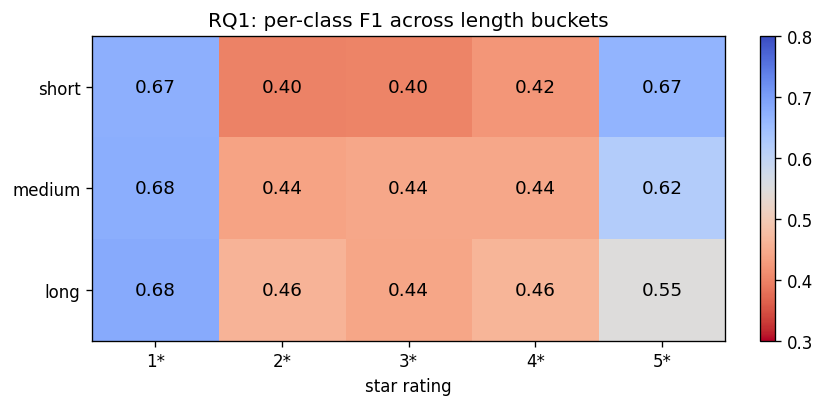

In [44]:
# heatmap
os.makedirs("assets", exist_ok=True)

fig, ax = plt.subplots(figsize=(7, 3.5))
im = ax.imshow(f1_table.values, cmap="coolwarm_r", vmin=0.3, vmax=0.8, aspect="auto")
ax.set_xticks(range(5))
ax.set_xticklabels([f"{s}*" for s in f1_table.columns])
ax.set_yticks(range(3))
ax.set_yticklabels(f1_table.index)
ax.set_xlabel("star rating")
ax.set_title("RQ1: per-class F1 across length buckets")
for i in range(f1_table.shape[0]):
    for j in range(f1_table.shape[1]):
        ax.text(j, i, f"{f1_table.iat[i, j]:.2f}", ha="center", va="center", fontsize=11)
plt.colorbar(im, ax=ax, fraction=0.04)
plt.tight_layout()
plt.savefig("assets/rq1_length_heatmap.png", dpi=200, bbox_inches="tight")
plt.show()

#### Verdict

Overall accuracy is flat across the three buckets at 53.4, 52.4, and 52.2 percent. The per-class numbers move in different directions. The 1 star F1 stays around 0.67 regardless of length. The 5 star F1 drops from 0.67 in short reviews to 0.55 in long reviews. The middle ratings all gain a few points as reviews get longer.

This shrinks the gap between extreme and middle ratings from about 0.25 in short reviews to about 0.17 in long reviews. Length does not cause the gap, but it changes its size. Longer middle reviews give the classifier more usable tokens, while longer 5 star reviews tend to include qualifying language that pulls them closer to 4 star.

### 3.3 RQ2: Does the Representation Choice Change the Gap?

The pilot in Checkpoint 2 showed that TF-IDF beats CountVectorizer overall. The question here is whether that gain is spread evenly across all five classes, or whether it shows up mostly in extreme ratings, middle ratings, or one specific class.

Setup:
- same 20K training sample as RQ1
- both models share the same Logistic Regression and vocabulary cap, only the vectorizer differs
- evaluation on the full 50K test set, both overall and per class

In [26]:
# both train on the same 20K sample
y_train_s = train_sample["label"].values
y_test = test_df["label"].values

cv = CountVectorizer(max_features=20000, min_df=5, stop_words="english")
Xtr_cv = cv.fit_transform(train_sample["text_clean"])
Xte_cv = cv.transform(test_df["text_clean"])

In [27]:
clf_cv = LogisticRegression(max_iter=1000)
clf_cv.fit(Xtr_cv, y_train_s)
pred_cv = clf_cv.predict(Xte_cv)

In [28]:
tfidf2 = TfidfVectorizer(max_features=20000, min_df=5, stop_words="english")
Xtr_tf = tfidf2.fit_transform(train_sample["text_clean"])
Xte_tf = tfidf2.transform(test_df["text_clean"])

In [29]:
clf_tf = LogisticRegression(max_iter=1000)
clf_tf.fit(Xtr_tf, y_train_s)
pred_tf = clf_tf.predict(Xte_tf)

In [30]:
# eval both
results_overall = pd.DataFrame({
    "method": ["CountVec + LR", "TF-IDF + LR"],
    "accuracy": [
        accuracy_score(y_test, pred_cv),
        accuracy_score(y_test, pred_tf),
    ],
    "macro_f1": [
        f1_score(y_test, pred_cv, average="macro"),
        f1_score(y_test, pred_tf, average="macro"),
    ],
})

In [31]:
results_overall.round(4)

,method,accuracy,macro_f1
0,CountVec + LR,0.4891,0.4875
1,TF-IDF + LR,0.5266,0.5232


In [32]:
# per-class F1 with the gain from switching to TF-IDF
labels = [0, 1, 2, 3, 4]
f1_cv = f1_score(y_test, pred_cv, labels=labels, average=None, zero_division=0)
f1_tf = f1_score(y_test, pred_tf, labels=labels, average=None, zero_division=0)

In [33]:
per_class_cmp = pd.DataFrame({
    "star": [1, 2, 3, 4, 5],
    "count_f1": f1_cv,
    "tfidf_f1": f1_tf,
    "delta": f1_tf - f1_cv,
})

per_class_cmp.round(4)

,star,count_f1,tfidf_f1,delta
0,1,0.6346,0.6779,0.0433
1,2,0.4042,0.4376,0.0334
2,3,0.3963,0.4315,0.0352
3,4,0.4112,0.4424,0.0312
4,5,0.5912,0.6264,0.0352


In [ ]:
# confusion matrices
cm_cv = confusion_matrix(y_test, pred_cv, normalize="true")
cm_tf = confusion_matrix(y_test, pred_tf, normalize="true")

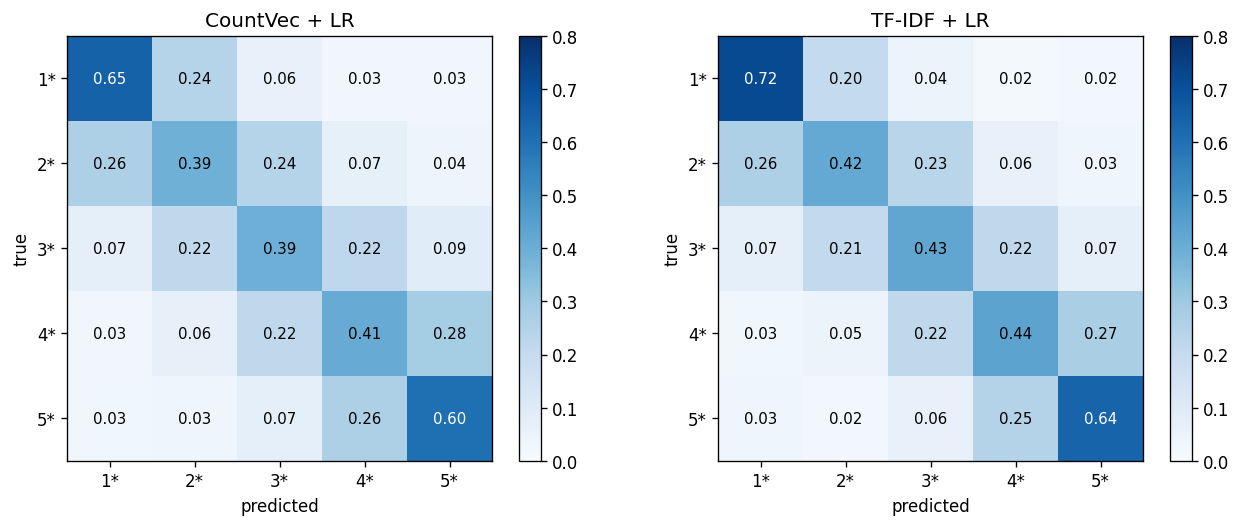

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, cm, title in zip(axes, [cm_cv, cm_tf], ["CountVec + LR", "TF-IDF + LR"]):
    im = ax.imshow(cm, cmap="Blues", vmin=0, vmax=0.8)
    ax.set_xticks(range(5))
    ax.set_xticklabels([f"{s}*" for s in range(1, 6)])
    ax.set_yticks(range(5))
    ax.set_yticklabels([f"{s}*" for s in range(1, 6)])
    ax.set_xlabel("predicted")
    ax.set_ylabel("true")
    ax.set_title(title)
    for i in range(5):
        for j in range(5):
            ax.text(j, i, f"{cm[i, j]:.2f}", ha="center", va="center",
                    fontsize=9, color="black" if cm[i, j] < 0.5 else "white")
    plt.colorbar(im, ax=ax, fraction=0.04)
plt.tight_layout()
plt.savefig("assets/rq2_confusion.png", dpi=200, bbox_inches="tight")
plt.show()

#### Verdict

TF-IDF beats CountVectorizer on every class by a similar amount. 1 star sees a slightly larger boost than the others, but the differences across classes are small.

What matters more is what does not change. The gap between extreme and middle ratings sits at about 0.21 in both cases. A smarter weighting of bag-of-words tokens lifts the whole model uniformly, but it does not touch the source of the gap. Whatever makes 2, 3, and 4 star reviews hard for a TF-IDF baseline is also what makes them hard for CountVectorizer. The middle ratings are not held back by feature weighting. They are held back by something the bag-of-words family cannot fix on its own.

### 3.4 RQ3: Are Middle Reviews More Topically Mixed?

The first two questions stayed inside bag-of-words classification. RQ3 takes a different angle and asks whether middle ratings actually have a more mixed topic structure than extreme ratings. If yes, it gives a more interpretable reason why middle ratings are hard to pin down to a single label.

Setup:
- Latent Dirichlet Allocation with 5 topics, fit on a 10K random sample of training reviews
- features come from CountVectorizer with a smaller vocab cap (LDA scales worse with vocab)
- for every review, the LDA model returns a distribution over the 5 topics
- I compute the entropy of that distribution per review, then average it within each star rating

Higher entropy means the review sits on more than one topic at once. If the entropy is higher for middle ratings, that is direct evidence of more topic mixing.

In [37]:
# fit LDA on 10K, smaller vocab cap
N_LDA = 10000
lda_sample = train_df.sample(n=N_LDA, random_state=RANDOM_SEED)

cv_lda = CountVectorizer(max_features=5000, min_df=10, stop_words="english")
X_lda = cv_lda.fit_transform(lda_sample["text_clean"])

lda = LatentDirichletAllocation(n_components=5, random_state=RANDOM_SEED)
lda.fit(X_lda)

,"n_components n_components: int, default=10Number of topics... versionchanged:: 0.19 ``n_topics`` was renamed to ``n_components``",5
,"doc_topic_prior doc_topic_prior: float, default=NonePrior of document topic distribution `theta`. If the value is None,defaults to `1 / n_components`.In [1]_, this is called `alpha`.",None
,"topic_word_prior topic_word_prior: float, default=NonePrior of topic word distribution `beta`. If the value is None, defaultsto `1 / n_components`.In [1]_, this is called `eta`.",None
,"learning_method learning_method: {'batch', 'online'}, default='batch'Method used to update `_component`. Only used in :meth:`fit` method.In general, if the data size is large, the online update will be muchfaster than the batch update.Valid options:- 'batch': Batch variational Bayes method. Use all training data in each EM update. Old `components_` will be overwritten in each iteration.- 'online': Online variational Bayes method. In each EM update, use mini-batch of training data to update the ``components_`` variable incrementally. The learning rate is controlled by the ``learning_decay`` and the ``learning_offset`` parameters... versionchanged:: 0.20 The default learning method is now ``""batch""``.",'batch'
,"learning_decay learning_decay: float, default=0.7It is a parameter that control learning rate in the online learningmethod. The value should be set between (0.5, 1.0] to guaranteeasymptotic convergence. When the value is 0.0 and batch_size is``n_samples``, the update method is same as batch learning. In theliterature, this is called kappa.",0.7
,"learning_offset learning_offset: float, default=10.0A (positive) parameter that downweights early iterations in onlinelearning. It should be greater than 1.0. In the literature, this iscalled tau_0.",10.0
,"max_iter max_iter: int, default=10The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the :meth:`fit` method, and not the:meth:`partial_fit` method.",10
,"batch_size batch_size: int, default=128Number of documents to use in each EM iteration. Only used in onlinelearning.",128
,"evaluate_every evaluate_every: int, default=-1How often to evaluate perplexity. Only used in `fit` method.set it to 0 or negative number to not evaluate perplexity intraining at all. Evaluating perplexity can help you check convergencein training process, but it will also increase total training time.Evaluating perplexity in every iteration might increase training timeup to two-fold.",-1
,"total_samples total_samples: int, default=1e6Total number of documents. Only used in the :meth:`partial_fit` method.",1000000.0
,"perp_tol perp_tol: float, default=1e-1Perplexity tolerance. Only used when ``evaluate_every`` is greater than 0.",0.1


In [38]:
# top 10 words per topic
n_top = 10
terms = cv_lda.get_feature_names_out()

for k, comp in enumerate(lda.components_):
    top_idx = comp.argsort()[-n_top:][::-1]
    print(f"topic {k}:", ", ".join(terms[i] for i in top_idx))

topic 0: time, service, just, told, said, did, didn, room, got, like
topic 1: food, good, ordered, service, just, restaurant, like, came, place, chicken
topic 2: like, just, breakfast, good, cream, sandwich, place, cheese, ice, chocolate
topic 3: food, good, place, great, service, like, pizza, really, burger, ve
topic 4: place, like, just, great, good, really, vegas, bar, nice, people


In [39]:
# transform a 30K labeled sample, average per-review topic entropy by star rating
N_ENT = 30000
ent_sample = train_df.sample(n=N_ENT, random_state=RANDOM_SEED).copy()
X_ent = cv_lda.transform(ent_sample["text_clean"])
doc_topic = lda.transform(X_ent)

ent_sample["topic_entropy"] = [entropy(row) for row in doc_topic]
mean_ent = ent_sample.groupby("label")["topic_entropy"].mean()
mean_ent.round(4)

label
0    0.6676
1    0.7505
2    0.7631
3    0.7614
4    0.7358
Name: topic_entropy, dtype: float64

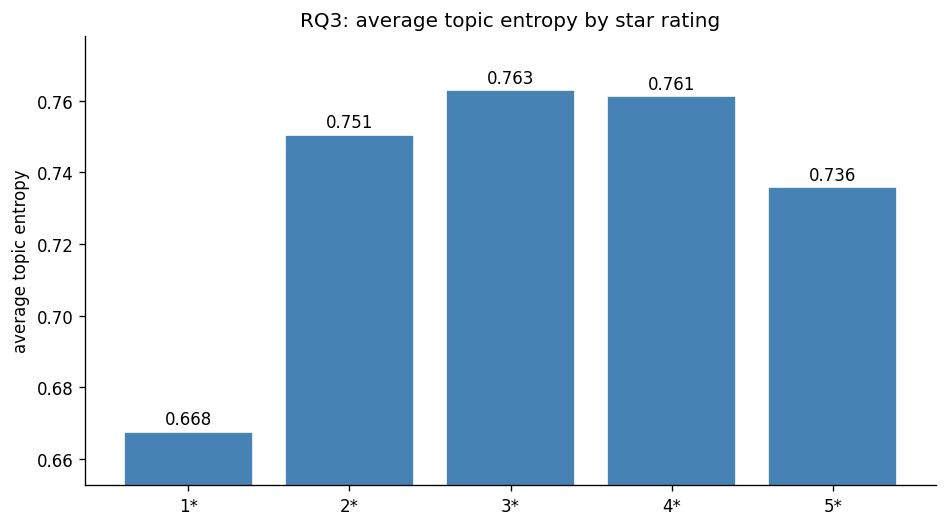

In [41]:
# plot average topic entropy
fig, ax = plt.subplots(figsize=(8, 4.5))
stars = [1, 2, 3, 4, 5]
ax.bar([f"{s}*" for s in stars], mean_ent.values, color="steelblue", edgecolor="white")

for i, v in enumerate(mean_ent.values):
    ax.text(i, v + 0.002, f"{v:.3f}", ha="center", fontsize=10)

ax.set_ylabel("average topic entropy")
ax.set_title("RQ3: average topic entropy by star rating")
ax.set_ylim(min(mean_ent.values) - 0.015, max(mean_ent.values) + 0.015)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("assets/rq3_entropy.png", dpi=200, bbox_inches="tight")
plt.show()

#### Verdict

The pattern in the entropy plot is striking. 1 star reviews have the lowest topic entropy at about 0.67, meaning they tend to stay on a single topic. Looking at the topic words, that single topic is almost certainly topic 0, the one full of service complaint words (time, service, told, said, did, didn). When customers leave a 1 star review, they usually have one bad story to tell, and they tell it.

5 star reviews come in a little higher at about 0.74. Praise often covers more than one aspect like food, service, or atmosphere, but it still hangs together.

The middle ratings sit at the top of the entropy curve, with 3 star at 0.76 and 2 and 4 star close behind. These reviews actually do mix topics more than either extreme. A 3 star review is often something like "the food was great but the service ruined it", which by construction pulls the document across multiple topics in the LDA space.

This is the most interpretable answer to the original puzzle. Bag-of-words classifiers struggle on middle ratings because middle reviews do not stick to a single topic. They blend across multiple ones, and a single star label cannot capture the blend.

## 4. Analysis & Conclusion

The three research questions each look at why middle star ratings are harder to classify than extreme ones. RQ1 showed that length affects the gap without causing it. The gap exists in every length bucket, and its size changes only modestly across short, medium, and long reviews. Length gives middle ratings a little more material to work with and tends to hurt 5 star reviews because long praise often comes with qualifications. None of this creates the gap on its own.

RQ2 showed that the choice of vectorizer multiplies performance roughly evenly across all five classes. TF-IDF lifts every class by about 0.03 to 0.04 in F1, so the gap is preserved. A smarter weighting of bag-of-words tokens cannot fix something that is not a weighting problem.

RQ3 is where a real explanation appeared. Middle ratings have measurably higher topic entropy than extreme ratings. They genuinely span more topics per review, with 3 star reviews sitting at the top of the entropy curve. A 3 star review usually mixes positive and negative impressions across different aspects of the visit, and the resulting document looks like several focused reviews mixed into one. Bag-of-words classification has no way to express that blend, so it picks one label and is wrong on the rest.

The takeaway is clear. The gap in this dataset is not a feature engineering problem. It is something deeper: middle ratings carry mixed content that a bag-of-words representation cannot disentangle. To close the gap, the model needs to encode the mixed nature of these reviews instead of collapsing them onto a single feature axis. Transformer embeddings, ordinal regression that respects the adjacency of star ratings, and aspect-based sentiment models are all reasonable next steps.

A few limitations are worth noting. The LDA used 5 topics on a 10K sample, and neither the topic count nor the sample size was tuned, so the entropy comparison is descriptive rather than carefully optimized. All classifiers use the same Logistic Regression and the same vocabulary cap, so I cannot rule out that a different classifier would interact differently with TF-IDF. And the 5 star label is itself a noisy target because users disagree about what a 3 star rating means in practice.

## Reproducibility

The cells below print the Python version this notebook was run on and write a full `requirements.txt` to the repo root. Anyone cloning the repo can install the same environment with `pip install -r requirements.txt`.

In [42]:
!python --version

Python 3.11.7


In [43]:
# full env snapshot at repo root
!pip freeze > requirements.txt